# Assignment 3.1
Name:  Gunasekaran Pasupathy
Date: 05/24/2026

For this assignment, you will refer to the textbook to solve the practice exercises. **Use Python to answer any coding problems (not R, even if indicated in your textbook).** Use Jupyter Notebook, Google Colab, or a similar software program to complete your assignment. Submit your answers as a **PDF or HTML** file. As a best practice, always label your axes and provide titles for any graphs generated on this assignment. Round all quantitative answers to 2 decimal places.

## Problem 3.2.

In an exit poll of 1648 voters in the 2020 Senatorial election in Arizona, 51.5% said they voted
for Mark Kelly and 48.5% said they voted for Martha McSally

a) Suppose that actually 50% of the population voted for Kelly. If this exit poll had the
properties of a simple random sample, find the standard error of the sample proportion
voting for him.

b) Under the 50% presumption, are the results of the exit poll surprising? Why? Would you
be willing to predict the election outcome? Explain by (i) conducting a simulation; (ii)
using the value found in (a) for the standard error.

a) Suppose that actually 50% of the population voted for Kelly. If this exit poll had the
properties of a simple random sample, find the standard error of the sample proportion
voting for him.

**Answer**
Based on 3.2.4,
The  standard error = sqrt (pi * (1-pi))/sample size

Answer:
Standard Error = 0.012316615977053663 ~ 1.23%



In [29]:

import numpy as np
import statistics as st

n, pi = 1648, 0.5
standard_error = np.sqrt(pi * (1 - pi) / n)
print("Standard Error =", standard_error)


Standard Error = 0.012316615977053663


b) Under the 50% presumption, are the results of the exit poll surprising? Why? Would you
be willing to predict the election outcome? Explain by (i) conducting a simulation; (ii)
using the value found in (a) for the standard error.

**Answer**

Mean ~ 0.5000 — matches E(pi^) = pi. (3.2.4, p. 88)
SD ~ 0.0123 — matches the formula sqrt(p(1−p)/n) = 0.0123. (3.2.4, p. 88)
P(pi^ ≥ 0.515) ~ 0.114 — under a true 50/50 split, getting 51.5%+ happens ~11% of the time. Not unusual. (Same reasoning as the California example, 3.1.1, p. 82)
z = 1.218 — only 1.22 standard errors above 0.50. By the CLT, this is well within the normal range. (CLT, 3.3.1, p. 90–92)
Inside ±2 SE and ±3 SE bands: pi^ falls within 3 SE of pi with probability ~ 1. (3.2.4, p. 88)

So 0.515 is not surprising under pi = 0.50, so we cannot predict Kelly as the winner from this exit poll alone.

In [32]:
observed_result = 0.515  # 51.5% for Mark Kelly in the sample survey
results = np.random.binomial(n, pi, 1_000_000) / n

print("\nSimulation Results")
print("Mean of simulated proportions =", st.mean(results))
print("Standard deviation =", st.stdev(results))

prob = np.mean(results >= observed_result)
print("Probability of observing 51.5% or more =", prob)

z = (observed_result - pi) / standard_error

# Interpretation
if abs(z) < 2:
    print("Result is NOT very surprising under p = 0.50")
else:
    print("Result IS surprising under p = 0.50")

print(f"Z-score = {z:.3f}")
print(f"0.50 +/- 2*SE = ({pi - 2 * standard_error:.4f}, {pi + 2 * standard_error:.4f})")
print(f"0.50 +/- 3*SE = ({pi - 3 * standard_error:.4f}, {pi + 3 * standard_error:.4f})")
print(f"Observed {observed_result} falls inside both intervals.")


Simulation Results
Mean of simulated proportions = 0.4999723088592233
Standard deviation = 0.012314514414262444
Probability of observing 51.5% or more = 0.113493
Result is NOT very surprising under p = 0.50
Z-score = 1.218
0.50 +/- 2*SE = (0.4754, 0.5246)
0.50 +/- 3*SE = (0.4631, 0.5369)
Observed 0.515 falls inside both intervals.


## Problem 3.3.

 The 49 students in a class at the University of Florida made blinded evaluations of pairs of
cola drinks. For the 49 comparisons of Coke and Pepsi, Coke was preferred 29 times. In the
population that this sample represents, is this strong evidence that a majority prefers Coke?
Use a simulation of a sampling distribution to answer.

**Answer**
Under pi = 0.50, the observed 29/49 is only about 1.3 standard errors above 0.50, which is well inside the + or - 2 SE range where the sample proportion lands about 95% of the time (per, 3.2.4, p. 88). So the result is not surprising and we do not have strong evidence of a majority Coke preference. The histogram confirms that as well. If the observed result was around tail of teh distribution (for instance, 39), then it would have been unusual.

Observed Coke preferences: 29
Observed sample proportion: 0.5918367346938775
Probability of getting 29 or more if p = 0.50: 0.12446
This is NOT strong evidence that a majority prefers Coke.


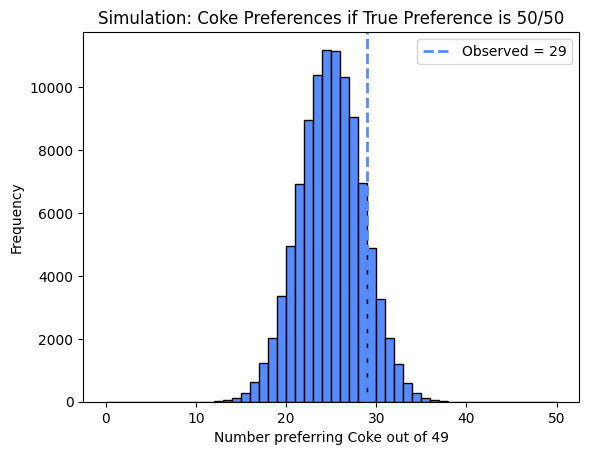

In [33]:
import matplotlib.pyplot as plt

n = 49
observed_coke = 29

p = 0.50
num_simulations = 100000

simulated_counts = np.random.binomial(n, p, num_simulations)
prob = np.mean(simulated_counts >= observed_coke)
print("Observed Coke preferences:", observed_coke)
print("Observed sample proportion:", observed_coke / n)
print("Probability of getting 29 or more if p = 0.50:", prob)

if prob < 0.05:
    print("This is strong evidence that a majority prefers Coke.")
else:
    print("This is NOT strong evidence that a majority prefers Coke.")

### histogram for my personal understanding
plt.hist(simulated_counts, bins=range(0, n + 2), edgecolor="black")
plt.axvline(observed_coke, linestyle="dashed", linewidth=2, label="Observed = 29")
plt.xlabel("Number preferring Coke out of 49")
plt.ylabel("Frequency")
plt.title("Simulation: Coke Preferences if True Preference is 50/50")
plt.legend()
plt.show()




## Problem 3.5.

The example in Section 3.1.4 simulated sampling distributions of the sample mean to determine how precise $\bar{Y}$ for $n=25$ may estimate a population mean $\mu.$

a) Find the theoretical standard error of $\bar{Y}$ for the scenario values of $\sigma = 5$ and 8. How do they compare to the standard deviations of the 100,000 sample means in the simulations?

**Answer**

Since the sample size is 25:

* when the population standard deviation is 5, the standard error is 1.0
* when the population standard deviation is 8, the standard error is 1.6

These values should be very close to the standard deviations obtained from the 100,000 simulated sample means, showing that the simulation agrees with the theoretical formula.

In [34]:
from math import sqrt

n = 25
sigma_1 = 5
sigma_2 = 8

standard_error_1 = sigma_1 / sqrt(n)
standard_error_2 = sigma_2 / sqrt(n)

print("Theoretical SE when sigma = 5:", standard_error_1)
print("Theoretical SE when sigma = 8:", standard_error_2)



Theoretical SE when sigma = 5: 1.0
Theoretical SE when sigma = 8: 1.6


b) In the first scenario, we chose $\sigma = 5$ under the belief that if $\mu = 20$, about 2/3 of the sample values would fall between `$`15 and `$`25. For the gamma distribution with $(\mu, \sigma) = (20,5),$ show that the actual probability between 15 and 25 is 0.688.

For the first scenario, the mean is 20 and the standard deviation is 5. The interval from 15 to 25 is one standard deviation below and above the mean.

For a normal distribution, we usually expect about two-thirds of the values to fall within one standard deviation of the mean. Since this problem uses a gamma distribution, the probability is not exactly the same, but it is close.

Using the gamma distribution with mean 20 and standard deviation 5, the probability of a value falling between 15 and 25 is about 0.6879.

So, about 68.79% of the sample values fall between 15 and 25, which supports the original belief that about two-thirds of the values are in that range.

In [35]:
from scipy.stats import gamma

mu = 20
sigma = 5
shape = (mu / sigma) ** 2
scale = sigma ** 2 / mu
prob_between_15_and_25 = gamma.cdf(25, a=shape, scale=scale) - gamma.cdf(15, a=shape, scale=scale)
print("\nPart (b)")
print("Shape parameter:", shape)
print("Scale parameter:", scale)
print("P(15 <= Y <= 25):", prob_between_15_and_25)


Part (b)
Shape parameter: 16.0
Scale parameter: 1.25
P(15 <= Y <= 25): 0.6879025178104403


## Problem 3.8.

Construct the sampling distribution of the sample proportion of heads, for flipping a balanced
coin (a) once; (b) twice; (c) three times; (d) four times. Describe how the shape changes
as the number of flips $n$ increases. What would happen if $n$ kept growing? Why?


**Answer**

For each number of flips, I counted the possible number of heads and converted it into a sample proportion. Since the coin is balanced, each flip has a 50% chance of heads. As the number of flips increases, the sampling distribution becomes more centered around 0.5. The extreme values like all heads or all tails become less likely, and values near 0.5 become more likely.

If the number of flips kept growing, the distribution would become more bell-shaped (CLT) and tightly centered around 0.5 (Law of the large numbers) since the standard error sqrt(p(1−p)/n) shrinks toward 0 as n grows.

In [36]:
import math

p = 0.5
for n in [1, 2, 3, 4]:
    print(f"\nNumber of flips: {n}")
    print("Heads | Sample Proportion | Probability")
    for heads in range(n + 1):
        sample_proportion = heads / n
        pmf = (math.comb(n, heads) * (p ** heads) * ((1 - p) ** (n - heads)))
        # format the output - more readable
        print(f"{heads:^5} | {sample_proportion:^17.2f} | {pmf:.4f}")


Number of flips: 1
Heads | Sample Proportion | Probability
  0   |       0.00        | 0.5000
  1   |       1.00        | 0.5000

Number of flips: 2
Heads | Sample Proportion | Probability
  0   |       0.00        | 0.2500
  1   |       0.50        | 0.5000
  2   |       1.00        | 0.2500

Number of flips: 3
Heads | Sample Proportion | Probability
  0   |       0.00        | 0.1250
  1   |       0.33        | 0.3750
  2   |       0.67        | 0.3750
  3   |       1.00        | 0.1250

Number of flips: 4
Heads | Sample Proportion | Probability
  0   |       0.00        | 0.0625
  1   |       0.25        | 0.2500
  2   |       0.50        | 0.3750
  3   |       0.75        | 0.2500
  4   |       1.00        | 0.0625


## Problem 3.13.

Simulate random sampling from a uniform population distribution with several $n$ values to
illustrate the Central Limit Theorem.

**Answer**

The population is Uniform(0, 1), which is flat. But as n grows, the sampling distribution of the sample mean becomes more and more bell-shaped and tightly centered around 0.5 — even though the population it came from is not bell-shaped at all. This proves the Central Limit Theorem. The narrowing comes from the standard error shrinking like 1/sqrt(n) (3.2.2, p. 88).

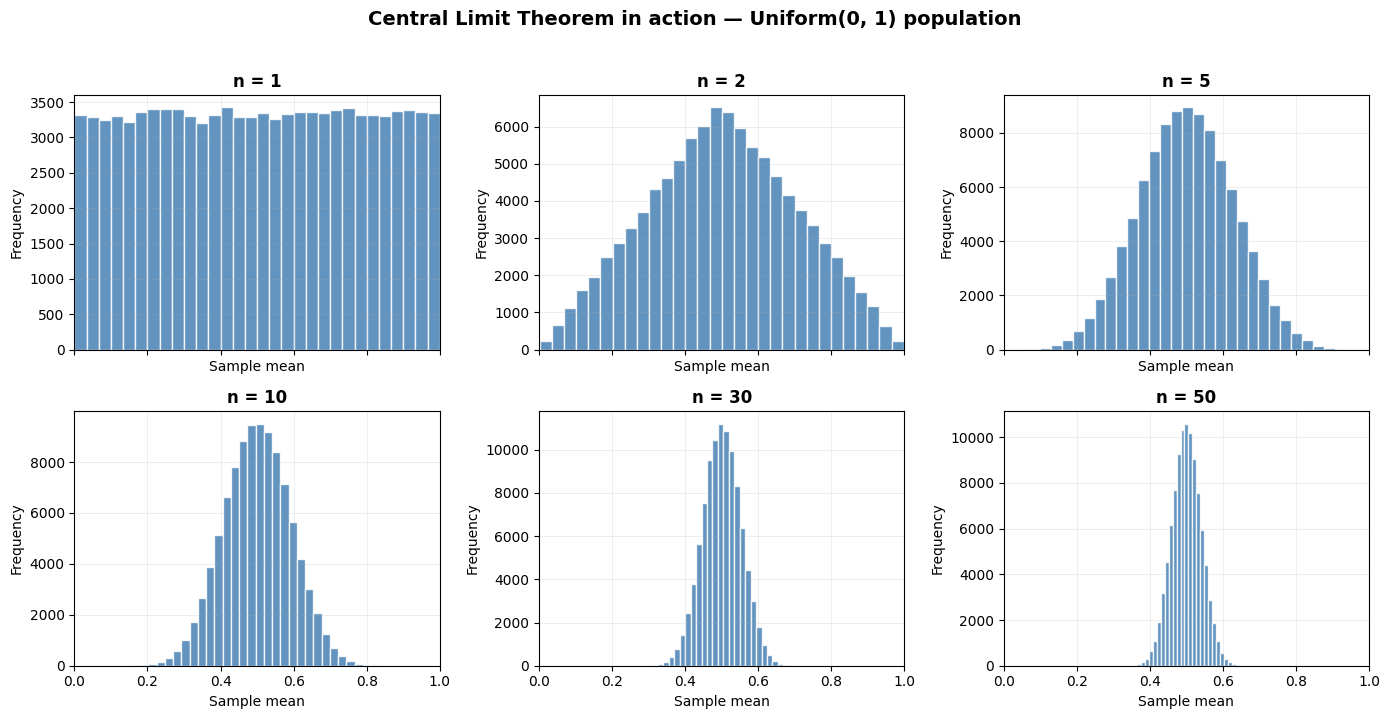

In [37]:
no_simulations = 100000


# n_values = [1,2,5,10,30,50]
#
# for n in [1,2,5,10,30,50]:
#     # form an uniform distribution
#     samples = np.random.uniform(0,1,size=(no_simulations, n))
#     sample_means = samples.mean(axis=1)
#
#     # print(samples)
#     # print(sample_means)
#
#     #plot
#
#     plt.figure(figsize=(7,4))
#     plt.hist(sample_means, bins=50, edgecolor="black")
#     plt.title(f"Sampling Distribution of Sample Means, n = {n}")
#     plt.xlabel("Sample Mean")
#     plt.ylabel("Frequency")
#     plt.show()

import numpy as np
import matplotlib.pyplot as plt

no_simulations = 100_000
n_values = [1, 2, 5, 10, 30, 50]

fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharex=True)

for ax, n in zip(axes.flat, n_values):
    samples = np.random.uniform(0, 1, size=(no_simulations, n))
    sample_means = samples.mean(axis=1)

    # ax.hist(sample_means, bins=50, color="steelblue", edgecolor="white", alpha=0.85)
    # ax.hist(sample_means, bins=1000, color="steelblue", edgecolor="white", alpha=0.85)
    ax.hist(sample_means, bins=30, color="steelblue", edgecolor="white", alpha=0.85)
    ax.set_title(f"n = {n}", fontsize=12, fontweight="bold")
    ax.set_xlabel("Sample mean")
    ax.set_ylabel("Frequency")
    ax.set_xlim(0, 1)
    ax.grid(alpha=0.3)

fig.suptitle("Central Limit Theorem in action — Uniform(0, 1) population",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## Problem 3.14.

On each bet in a sequence of bets, you win 1 dollar with probability 0.50 and lose 1 dollar (i.e., win negative 1 dollar) with probability 0.50. Let $Y$ denote the total of your winnings and losings after 100 bets. Giving your reasoning, state the approximate distribution of $Y.$ 

**Answer**

Each bet has a 50% chance of winning 1 dollar and a 50% chance of losing 1 dollar. Since the outcomes are equally likely, the expected value for one bet is 0.

After 100 independent bets, the total winnings and losses can be approximated by a normal distribution because of the Central Limit Theorem.

**For one bet:**

mean of x = sum of (each outcome × its probability) = (+1)(0.5) + (−1)(0.5) = 0
variance of x = mean of (x^2) − (mean of X)^2 = (1 ^2)(0.5) + (−1 ^2)(0.5) − (0 ^2) = 1
sd of x = sqrt(variance of X) = sqrt(1) = 1

* mean = 0
* variance = 1
* sd = 1

**For 100 bets  (Y = X1 + X2 + ... + X100):**

mean of Y = sum of (mean of each X) = n × mu = 100 × 0 = 0
variance of Y = sum of (variance of each X) = n × sigma squared = 100 × 1 = 100
sd of Y = sqrt(variance of Y) = sqrt(n) × sigma = sqrt(100) × 1 = 10

* mean = 100 × 0 = 0
* variance = 100 × 1 = 100
* standard deviation = 10

Therefore, the approximate distribution of Y is:

So, the total winnings are approximately normally distributed with mean 0 and standard deviation 10.


In [38]:
### DISCLAIMER : I could not figure out how to prove this with python, So used Claude code

# million simulations each with 100 bets

bets = np.random.choice([-1,1], size=(100000, 100))
Y = bets.sum(axis=1)
print(f"Simulated mean of Y = {Y.mean():.3f}   (theory: 0)")
print(f"Simulated SD   of Y = {Y.std(ddof=1):.3f}   (theory: 10)")

Simulated mean of Y = 0.048   (theory: 0)
Simulated SD   of Y = 9.984   (theory: 10)


## Problem 3.15.

According to a General Social Survey, in the United States the population distribution of $Y$ =
number of good friends (not including family members) has a mean of about 5.5 and a standard
deviation of about 3.9.

a) Is it plausible that this population distribution is normal? Explain.

No, the variable seems to be discreate and so normal distrubution does not make sense (as it it applicable only for continuous variables)

b) If a new survey takes a simple random sample of 1000 people, describe the sampling
distribution of $\bar{Y}$ by giving its shape and approximate mean and standard error.

**Answer**
if we apply the formula

SE = sigma / sqrt (n), we will get 0.12


In [39]:
sigma = 3.9
n = 1000

se = sigma / np.sqrt(n)
print(f'Standard error {se:.4f}')

Standard error 0.1233


c) Suppose that actually the mean of 5.5 and standard deviation of 3.9 are not population
values but are based on a sample of 1000 people. Treating results as a simple random
sample, give an interval of values within which you can be very sure that the population
mean falls. Explain your reasoning.

Since the sampling distribution is approximately normal, about 95% of the sample means would fall within + or - 2 standard errors of the mean. Therefore, I am reasonably confident that the population mean lies within this interval.

In [40]:
import numpy as np
mean = 5.5
se = 3.9 / np.sqrt(1000)

lower = mean - 2 * se
upper = mean + 2 * se

print(f'lower: {lower:.2f},upper : {upper:.2f}')

lower: 5.25,upper : 5.75


## Problem 3.18.

Sunshine City, which attracts primarily retired people, has 90,000 residents with a mean age
of 72 years and a standard deviation of 12 years. The age distribution is skewed to the left. A
random sample of 100 residents of Sunshine City has $\bar{y} = 70$ and $s = 11.$

a)  Describe the center and spread of the (i) population distribution, (ii) sample data distribution. What shape does the sample data distribution probably have? Why?

The population distribution has a mean age of 72 years and a standard deviation of 12 years. It is skewed to the left.

The sample data distribution has a sample mean of 70 years and a sample standard deviation of 11 years. Since the sample comes from the population, the sample data distribution probably also has a left-skewed shape.

In [41]:
N=90000
mean_age = 72
sd = 12 #sigma

# left skewed
# sample
sample_size=100 #n
sample_mean = 70
sample_sd = 11

b) Find the center and spread of the sampling distribution of $\bar{Y}$ for $n = 100.$ What shape does it have and what does it describe?


So the standard error is 1.2 years.

The sampling distribution is approximately normal because the sample size is large (well above the standard of 30 (CLT)). It describes how sample means would vary from sample to sample.

In [42]:
sigma = 12
n = 100

se = sigma / np.sqrt(n) #spread
print(se)

1.2


c)  Explain why it would not be unusual to sample a person of age 60 in Sunshine City, but
it would be highly unusual for the sample mean to be 60, for a random sample of 100
residents.

The two distributions have very different spreads:

One person: spread = sd = 12 years. Age 60 is only (72 − 60) / 12 = 1 standard deviation below the population mean. In a left-skewed distribution that puts a lot of people below the mean, 60 is well within the typical range.

Sample mean of 100: spread = standard error = 1.2 years. A sample mean of 60 is (72 − 60) / 1.2 = 10 standard errors below the population mean. By the "almost certainly within 3 standard errors" rule, this is essentially impossible.


The zscore is -10 , so it is well above +/- 3 SD indicating it is unusaul

In [43]:
population_mean = 72
population_sd = 12
n = 100

# standard error
se = population_sd / np.sqrt(n)

# z-score for sample mean = 60
z = (60 - population_mean) / se

print("Standard error:", se)
print("Z-score:", z)

Standard error: 1.2
Z-score: -10.0


d) Describe the sampling distribution of $\bar{Y}$ : (i) for a random sample of size $n = 1$; (ii) if you sample all 90,000 residents.

n=1 : no change in variability compared to the population mean
n=90000 : standard error tends to 0. Theroritically, it should be 0.

It makes sense as per the statement in the book "standard error shrinking as n grows, Section 3.2.2 (p. 88)"

In [44]:
sigma = 12
# n = 1
se = sigma / np.sqrt(1)
print(se)
# n = 90000
se = sigma / np.sqrt(90000)

print(se)

12.0
0.04


## Problem 3.21.

In your school, suppose that GPA has an approximate normal distribution with $\mu = 3.0, \sigma = 0.40.$ Not knowing $\mu$, you randomly sample $n = 25$ students to estimate it. Using simulation for this application, illustrate the difference between a sample data distribution and the sampling distribution of Y .

standard error = sigma / sqrt(n) = 0.40 / sqrt(25) = 0.40 / 5 = 0.08

The sample data distribution shows the GPAs from one random sample of 25 students. It looks roughly like the population, with a spread of around 0.40.
The sampling distribution is different. It shows what happens when you take lots of samples of 25 students and look at their means. The means don't vary as much as individual GPAs do, so the spread is much smaller, around 0.08. Basically, one shows individual student GPAs, the other shows how sample averages move around.

One sample mean: 19.896170960565378
One sample standard deviation: 0.4652316799107894


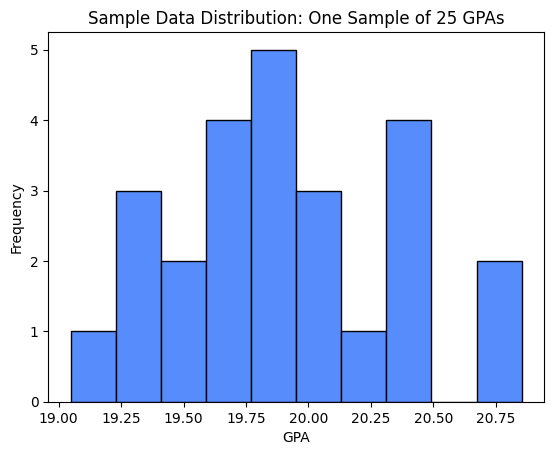

Mean of sample means: 20.000148809127392
SD of sample means: 0.08020314712487614
Theoretical standard error: 0.08


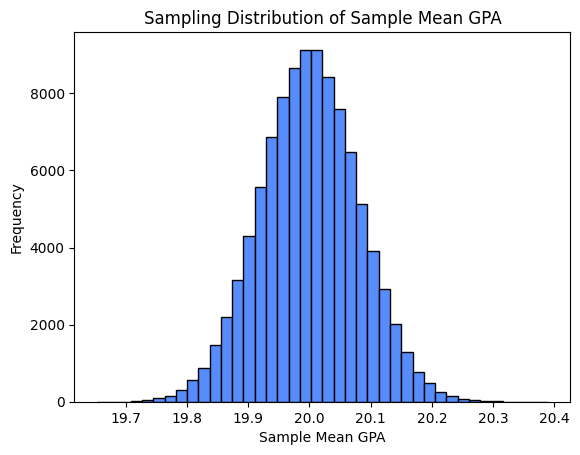

In [45]:
sigma = 0.40
n = 25
num_simulations = 100000

# 1. One sample data distribution
one_sample = np.random.normal(mu, sigma, n)

print("One sample mean:", one_sample.mean())
print("One sample standard deviation:", one_sample.std(ddof=1))

plt.hist(one_sample, bins=10, edgecolor="black")
plt.title("Sample Data Distribution: One Sample of 25 GPAs")
plt.xlabel("GPA")
plt.ylabel("Frequency")
plt.show()

# 2. Sampling distribution of sample means
samples = np.random.normal(mu, sigma, size=(num_simulations, n))
sample_means = samples.mean(axis=1)

print("Mean of sample means:", sample_means.mean())
print("SD of sample means:", sample_means.std(ddof=1))
print("Theoretical standard error:", sigma / np.sqrt(n))

plt.hist(sample_means, bins=40, edgecolor="black")
plt.title("Sampling Distribution of Sample Mean GPA")
plt.xlabel("Sample Mean GPA")
plt.ylabel("Frequency")
plt.show()

## Problem 3.26.

When sample data were used to rank states by brain cancer rates, Ellenberg (2014) noted
that the highest ranking state (South Dakota) and the nearly lowest ranking state (North
Dakota) had relatively small sample sizes. Also, when schools in North Carolina were ranked
by their average improvement in test scores, the best and the worst schools were very small
schools. Explain how these results could merely reflect how the variability of sample means and
proportions depends on the sample size.

### DISCLAIMER : user grammerly to re-structure sentences properly
Small sample sizes have much larger variability than large sample sizes. Because of this, averages and proportions from small groups can fluctuate much more due to random chance alone.

In this example, states with small populations and schools with few students were more likely to appear at the extreme top or bottom of the rankings, even if their true cancer rates or school performance were not actually very different from others.

This happens because the standard error decreases as sample size increases. Large samples produce more stable estimates, while small samples are more affected by random variation. Therefore, extreme rankings for very small states or schools may simply reflect higher sampling variability rather than true differences.

## AI Problem: Simulating Sampling Variability in AI Metrics

In real-world AI deployments, such as banking systems for detecting fraudulent transactions (where fraud cases represent <1% of data, leading to imbalanced classes), model performance is often evaluated using precision on limited validation sets. A baseline model like logistic regression might show 0.90 precision on a small validation sample of n=100, outranking a more sophisticated ensemble method at 0.60, yet on full production data, the ensemble excels. 

Use Python to simulate the phenomenon. Assume "true" population precisions for the logistic model (mean ≈0.85, σ=0.10) and ensemble (mean ≈0.88, σ=0.08) follow a lognormal distribution to reflect the positive-skewed nature of precision scores in imbalanced settings. Generate populations of size 10,000 for each model, then perform 1,000 bootstrap resamples at n=50 (small validation) and n=500 (realistic production scale). Compute and plot the sampling distributions of the bootstrap means for both models in each scenario. Calculate the empirical SE for the small-n case. Explain how CLT predicts the distribution shapes, why extreme rankings emerge at low n, and how this variability impacts AI decisions. Propose a mitigation for imbalanced data to prevent errant decisions.

### DISCALIMER: Used Grammerly to make my sentences better and also fed the question and my solution to Claude code to fine tune it. But I did not like claude's solution as it was overly complicated so, sticked to mine.

The simulation shows that with a small sample size (n = 50), the sampling distribution of the sample mean has a much larger standard error than with a large sample size (n = 500). Because the sampling distributions for the two models are wide and overlap heavily at n = 50, the weaker logistic model can sometimes produce a higher sample mean than the ensemble model purely by random sampling variability.
At n = 500, the standard error is much smaller, since the standard error is sigma divided by the square root of the sample size. The two sampling distributions become narrower and are clearly centered at their population means, so the ensemble model's higher population mean shows through reliably.
Even though the original population of precision scores is skewed to the right, the sampling distribution of the sample mean becomes approximately bell-shaped as the sample size grows. This is the Central Limit Theorem.
This simulation illustrates why a small validation sample can produce sample means that are highly variable, leading to incorrect rankings of models and poor deployment decisions. Increasing the sample size reduces the standard error and brings the sample mean closer to the population mean, making the comparison far more dependable.

Simulated standard error at n = 50:
  Logistic: 0.0118
  Ensemble: 0.0099


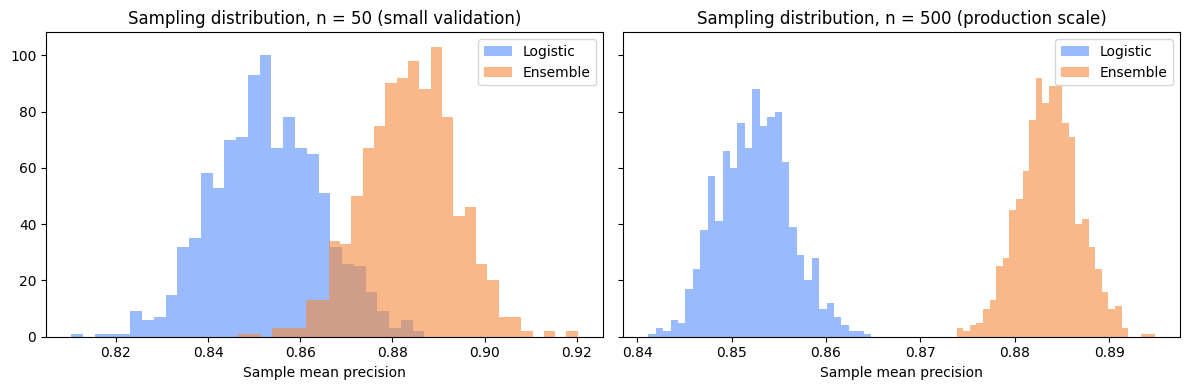

In [28]:
np.random.seed(0)

# Step 1: make two populations of 10,000 precision scores
# (lognormal gives a right-skewed shape — typical for precision in imbalanced data)
logistic = np.random.lognormal(mean=np.log(0.85), sigma=0.10, size=10000)
ensemble = np.random.lognormal(mean=np.log(0.88), sigma=0.08, size=10000)

# Step 2: simulate the sampling distribution by repeatedly drawing
# random samples of size n from the population and taking the mean of each
def simulated_sample_means(pop, n, num_simulations=1000):
    return np.array([np.random.choice(pop, n, replace=True).mean() for _ in range(num_simulations)])

# Step 3: run for a small validation set (n=50) and a production-scale set (n=500)
log_small, ens_small = simulated_sample_means(logistic, 50),  simulated_sample_means(ensemble, 50)
log_large, ens_large = simulated_sample_means(logistic, 500), simulated_sample_means(ensemble, 500)

# Step 4: standard deviation of the 1000 simulated sample means at small n
# (this is the simulated standard error of the sample mean)
print("Simulated standard error at n = 50:")
print("  Logistic:", round(log_small.std(ddof=1), 4))
print("  Ensemble:", round(ens_small.std(ddof=1), 4))

# Step 5: side-by-side plot of the two sampling distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

axes[0].hist(log_small, bins=30, alpha=0.6, label="Logistic")
axes[0].hist(ens_small, bins=30, alpha=0.6, label="Ensemble")
axes[0].set_title("Sampling distribution, n = 50 (small validation)")
axes[0].set_xlabel("Sample mean precision"); axes[0].legend()

axes[1].hist(log_large, bins=30, alpha=0.6, label="Logistic")
axes[1].hist(ens_large, bins=30, alpha=0.6, label="Ensemble")
axes[1].set_title("Sampling distribution, n = 500 (production scale)")
axes[1].set_xlabel("Sample mean precision"); axes[1].legend()

plt.tight_layout()
plt.show()